In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)


# LOAD DATA
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")



In [7]:
# TEXT + LABEL

X_train = train_df["text"].astype(str)
y_train = train_df["label_id"]

X_val = val_df["text"].astype(str)
y_val = val_df["label_id"]

X_test = test_df["text"].astype(str)
y_test = test_df["label_id"]


In [8]:
# TOKENIZE

MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    train_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_val_pad = pad_sequences(
    val_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=MAX_LEN,
    padding='post'
)

In [9]:
# BUILD TEXTCNN MODEL
model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
# COMPILE
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_textcnn.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# TRAIN
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint
    ]
)


Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7390 - loss: 0.5187
Epoch 1: val_accuracy improved from None to 0.92070, saving model to best_textcnn.keras

Epoch 1: finished saving model to best_textcnn.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 57s 167ms/step - accuracy: 0.8223 - loss: 0.3956 - val_accuracy: 0.9207 - val_loss: 0.1944
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9240 - loss: 0.1891
Epoch 2: val_accuracy improved from 0.92070 to 0.93459, saving model to best_textcnn.keras

Epoch 2: finished saving model to best_textcnn.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 80s 162ms/step - accuracy: 0.9288 - loss: 0.1757 - val_accuracy: 0.9346 - val_loss: 0.1611
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9661 - loss: 0.0909
Epoch 3: val_accuracy improved from 0.93459 to 0.94310, saving model to best_textcnn.keras

Epoch 3: finished saving model to best_textcnn.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 53s 161ms/step - accuracy: 0.9634 -

In [12]:
# PREDICT
y_prob = model.predict(X_test_pad)

y_pred = (y_prob > 0.5).astype(int)

# flatten để tránh warning shape
y_prob = y_prob.flatten()
y_pred = y_pred.flatten()

# EVALUATE
acc = accuracy_score(y_test, y_pred)

roc = roc_auc_score(y_test, y_prob)

print("\nAccuracy :", format(acc, ".4f"))
print("ROC-AUC  :", format(roc, ".4f"))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step

Accuracy : 0.9458
ROC-AUC  : 0.9855

Classification Report:

              precision    recall  f1-score   support

           0     0.9522    0.9647    0.9584      1446
           1     0.9336    0.9111    0.9222       787

    accuracy                         0.9458      2233
   macro avg     0.9429    0.9379    0.9403      2233
weighted avg     0.9457    0.9458    0.9457      2233



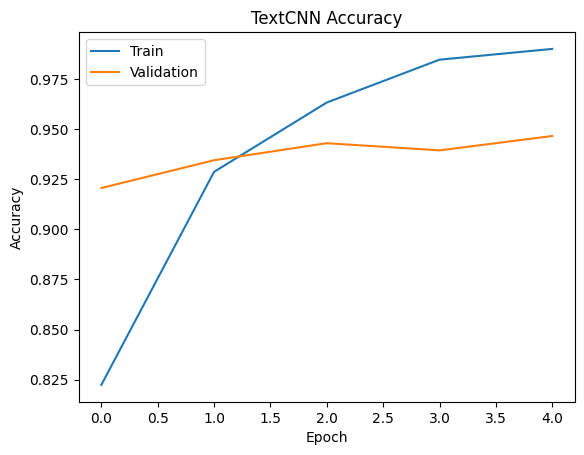

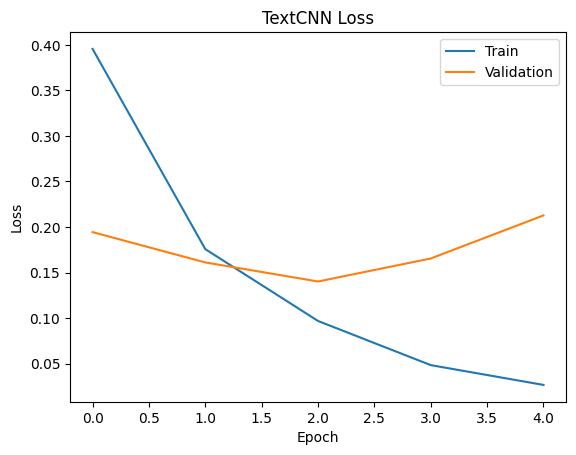

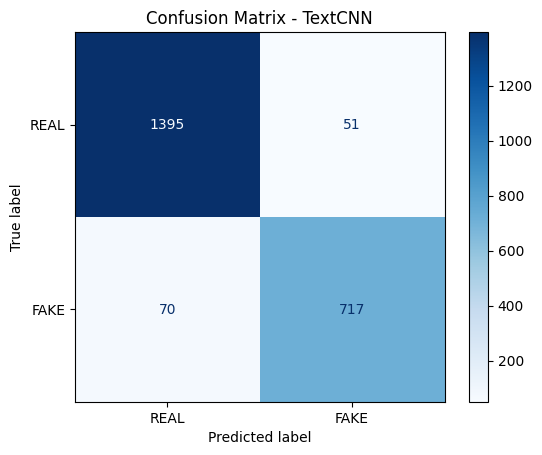


Model saved successfully!


In [13]:
# ACCURACY GRAPH
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("TextCNN Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()


# LOSS GRAPH
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("TextCNN Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - TextCNN")

plt.show()


# SAVE MODEL
model.save("textcnn_fake_news.h5")

print("\nModel saved successfully!")


In [14]:
# TEST NEW ARTICLE
sample_text = """
WHO xác nhận vaccine mới có hiệu quả chống biến thể mới của COVID-19.
"""

seq = tokenizer.texts_to_sequences([sample_text])

pad = pad_sequences(
    seq,
    maxlen=MAX_LEN,
    padding='post'
)

pred = model.predict(pad)[0][0]

print("\nPrediction Probability:", pred)

if pred > 0.5:
    print("FAKE NEWS")
else:
    print("REAL NEWS")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Prediction Probability: 0.26673612
REAL NEWS
